# 🧪 Atividade 1 — Primeira Investigação dos Dados (EDA)
## 📊 People Analytics: Análise e Previsão de Desligamento de Colaboradores

---
### 👥 Informações do Squad:
* **Integrantes**: Gabriel Maia, João Lucca, Kevin Mascarenhas, Marina Gonçalves e Samuel Paulo
* **Disciplina**: Data Science
* **Tema do Projeto**: People Analytics (Recursos Humanos)
* **Base de Dados**: `MFG10YearTerminationData.csv` (Histórico de 10 anos de colaboradores)

---
### 🎯 Objetivo da Atividade
Realizar uma primeira investigação exploratória sobre a base de dados de **People Analytics** para identificar padrões, relações e possíveis explicações para o problema de negócio (desligamento de colaboradores), transformando:
$$\text{Dados} \longrightarrow \text{Perguntas} \longrightarrow \text{Descobertas} \longrightarrow \text{Hipóteses}$$

---
## ⚙️ 0. Configuração do Ambiente e Carregamento dos Dados

Importação das bibliotecas para manipulação de dados, estatística descritiva e visualização gráfica (`pandas`, `numpy`, `matplotlib`, `seaborn`, `plotly`).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

# Configurações visuais e supressão de warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Carregamento dinâmico do dataset (funciona tanto no Google Colab quanto em ambiente local)
caminho_arquivo = 'MFG10YearTerminationData.csv' if os.path.exists('MFG10YearTerminationData.csv') else '/content/MFG10YearTerminationData.csv'
df = pd.read_csv(caminho_arquivo)

print(f"Dataset carregado com sucesso!")
print(f"Dimensões: {df.shape[0]:,} linhas e {df.shape[1]} colunas.")
df.head()

Dataset carregado com sucesso!
Dimensões: 49,653 linhas e 18 colunas.


,EmployeeID,recorddate_key,birthdate_key,orighiredate_key,terminationdate_key,age,length_of_service,city_name,department_name,job_title,store_name,gender_short,gender_full,termreason_desc,termtype_desc,STATUS_YEAR,STATUS,BUSINESS_UNIT
0,1318,12/31/2006 0:00,1/3/1954,8/28/1989,1/1/1900,52,17,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2006,ACTIVE,HEADOFFICE
1,1318,12/31/2007 0:00,1/3/1954,8/28/1989,1/1/1900,53,18,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2007,ACTIVE,HEADOFFICE
2,1318,12/31/2008 0:00,1/3/1954,8/28/1989,1/1/1900,54,19,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2008,ACTIVE,HEADOFFICE
3,1318,12/31/2009 0:00,1/3/1954,8/28/1989,1/1/1900,55,20,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2009,ACTIVE,HEADOFFICE
4,1318,12/31/2010 0:00,1/3/1954,8/28/1989,1/1/1900,56,21,Vancouver,Executive,CEO,35,M,Male,Not Applicable,Not Applicable,2010,ACTIVE,HEADOFFICE


In [2]:
# Verificação dos tipos de dados e valores nulos
print("--- Informações Estruturais do Dataset ---")
df.info()
print("\n--- Valores Ausentes por Coluna ---")
print(df.isnull().sum())

--- Informações Estruturais do Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 49653 entries, 0 to 49652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   EmployeeID           49653 non-null  int64
 1   recorddate_key       49653 non-null  str  
 2   birthdate_key        49653 non-null  str  
 3   orighiredate_key     49653 non-null  str  
 4   terminationdate_key  49653 non-null  str  
 5   age                  49653 non-null  int64
 6   length_of_service    49653 non-null  int64
 7   city_name            49653 non-null  str  
 8   department_name      49653 non-null  str  
 9   job_title            49653 non-null  str  
 10  store_name           49653 non-null  int64
 11  gender_short         49653 non-null  str  
 12  gender_full          49653 non-null  str  
 13  termreason_desc      49653 non-null  str  
 14  termtype_desc        49653 non-null  str  
 15  STATUS_YEAR          49653 non-null  i

In [3]:
# Resumo estatístico das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
EmployeeID,49653.0,4859.495740,1826.571142,1318.0,3360.0,5031.0,6335.0,8336.0
age,49653.0,42.077035,12.427257,19.0,31.0,42.0,53.0,65.0
length_of_service,49653.0,10.434596,6.325286,0.0,5.0,10.0,15.0,26.0
store_name,49653.0,27.297605,13.514134,1.0,16.0,28.0,42.0,46.0
STATUS_YEAR,49653.0,2010.612612,2.845577,2006.0,2008.0,2011.0,2013.0,2015.0


---
## 🎯 1. Definição e Análise da Variável Alvo (`Target`)

### 📌 Variável Alvo: `STATUS`

* **Descrição**: A variável alvo `STATUS` indica a situação funcional do colaborador no registro anual da organização:
  * `ACTIVE`: O colaborador permanece ativo na empresa no ano de referência.
  * `TERMINATED`: O colaborador foi desligado da empresa (por aposentadoria, pedido de demissão voluntária ou layoff).

O objetivo do negócio é identificar os fatores associados ao desligamento para permitir que o time de Gente & Gestão atue preventivamente na retenção de talentos e no planejamento sucessório da organização.

In [4]:
# Contagem absoluta das classes
contagem_target = df['STATUS'].value_counts()
print("--- Contagem Absoluta da Variável Alvo ---")
print(contagem_target)

# Proporção percentual das classes
proporcao_target = df['STATUS'].value_counts(normalize=True) * 100
print("\n--- Proporção Percentual da Variável Alvo (%) ---")
print(proporcao_target.round(2))

--- Contagem Absoluta da Variável Alvo ---
STATUS
ACTIVE        48168
TERMINATED     1485
Name: count, dtype: int64

--- Proporção Percentual da Variável Alvo (%) ---
STATUS
ACTIVE        97.01
TERMINATED     2.99
Name: proportion, dtype: float64


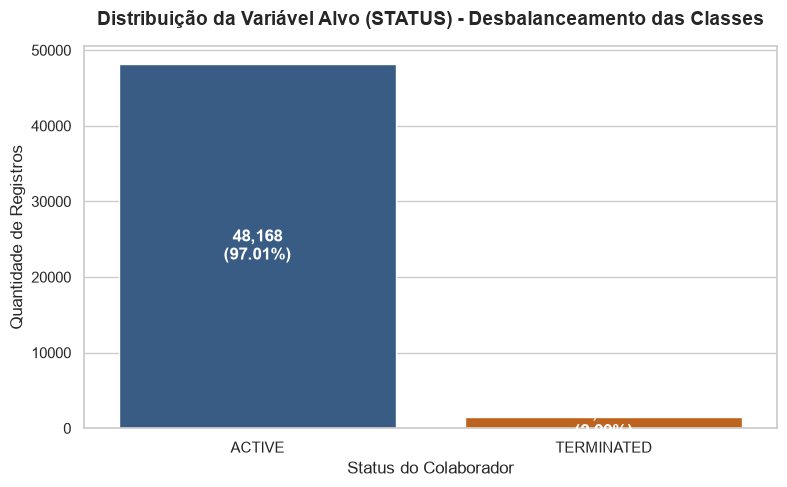

In [5]:
# Gráfico da Distribuição da Variável Alvo
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2b5c8f', '#d95f02']
sns.countplot(data=df, x='STATUS', palette=colors, ax=ax)

# Anotações de contagem e porcentagem em cima das barras
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percent = (height / total) * 100
    ax.annotate(f'{int(height):,}\n({percent:.2f}%)',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=12, color='white', fontweight='bold')

plt.title('Distribuição da Variável Alvo (STATUS) - Desbalanceamento das Classes', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status do Colaborador', fontsize=12)
plt.ylabel('Quantidade de Registros', fontsize=12)
plt.tight_layout()
plt.show()

> **⚠️ Observação sobre a Distribuição da Variável Alvo:**
> * **Ativos (`ACTIVE`)**: $48.168$ registros ($97,01\%$)
> * **Desligados (`TERMINATED`)**: $1.485$ registros ($2,99\%$)
> 
> A variável alvo apresenta um **desbalanceamento severo de classes**, o que é um comportamento esperado em problemas reais de rotatividade de RH (turnover anual em torno de 3% a 5%). Em etapas futuras de modelagem preditiva, será necessário utilizar métricas adequadas (como Precision, Recall, F1-Score e PR-AUC) e possíveis técnicas de balanceamento.

---
## 📋 2. Seleção e Justificativa dos Atributos

Para investigar os fatores associados ao desligamento, selecionamos os seguintes atributos:

| Atributo | Tipo | Por que investigar? (Justificativa) |
| :--- | :--- | :--- |
| **`age` (Idade)** | Numérica | Colaboradores mais jovens podem apresentar maior rotatividade voluntária no início da carreira, enquanto colaboradores mais velhos concentram desligamentos por aposentadoria. |
| **`length_of_service` (Tempo de Empresa)** | Numérica | Permite avaliar a curva de retenção: se os desligamentos ocorrem na fase de adaptação (novatos) ou por maturidade na organização (veteranos). |
| **`BUSINESS_UNIT` (Unidade de Negócio)** | Categórica | Unidades corporativas (`HEADOFFICE`) e operacionais (`STORES`) possuem dinâmicas, pressões de trabalho e estabilidade completamente distintas. |
| **`department_name` (Departamento)** | Categórica | Permite identificar se setores específicos (ex: Atendimento ao Cliente, TI, Produção) enfrentam gargalos de clima, retenção ou liderança. |
| **`termreason_desc` (Motivo do Desligamento)** | Categórica | Atributo indispensável para discriminar a natureza real da saída (`Resignaton`, `Retirement`, `Layoff`). |

---
## 🔍 3. Investigação dos Atributos

Seguindo estritamente a metodologia exigida na atividade, cada análise está registrada no formato:
* **Pergunta**: O que queremos descobrir?
* **Gráfico**: Qual gráfico foi utilizado?
* **Observação**: O que realmente apareceu nos dados?
* **Hipótese**: O que esse resultado pode indicar?

---
### 🔬 Análise 1: Numérica × Variável Alvo
#### Comportamento da Idade (`age`) e do Tempo de Serviço (`length_of_service`) por Status

In [6]:
# Estatísticas descritivas comparativas
print("--- Estatísticas de Idade por Status ---")
print(df.groupby('STATUS')['age'].describe().round(2))

print("\n--- Estatísticas de Tempo de Empresa (Anos) por Status ---")
print(df.groupby('STATUS')['length_of_service'].describe().round(2))

--- Estatísticas de Idade por Status ---
              count   mean    std   min   25%   50%   75%   max
STATUS                                                         
ACTIVE      48168.0  41.79  12.17  19.0  31.0  42.0  52.0  65.0
TERMINATED   1485.0  51.46  16.52  19.0  34.0  60.0  65.0  65.0

--- Estatísticas de Tempo de Empresa (Anos) por Status ---
              count   mean   std  min  25%   50%   75%   max
STATUS                                                      
ACTIVE      48168.0  10.41  6.31  0.0  5.0  10.0  15.0  26.0
TERMINATED   1485.0  11.36  6.74  0.0  7.0  13.0  13.0  25.0


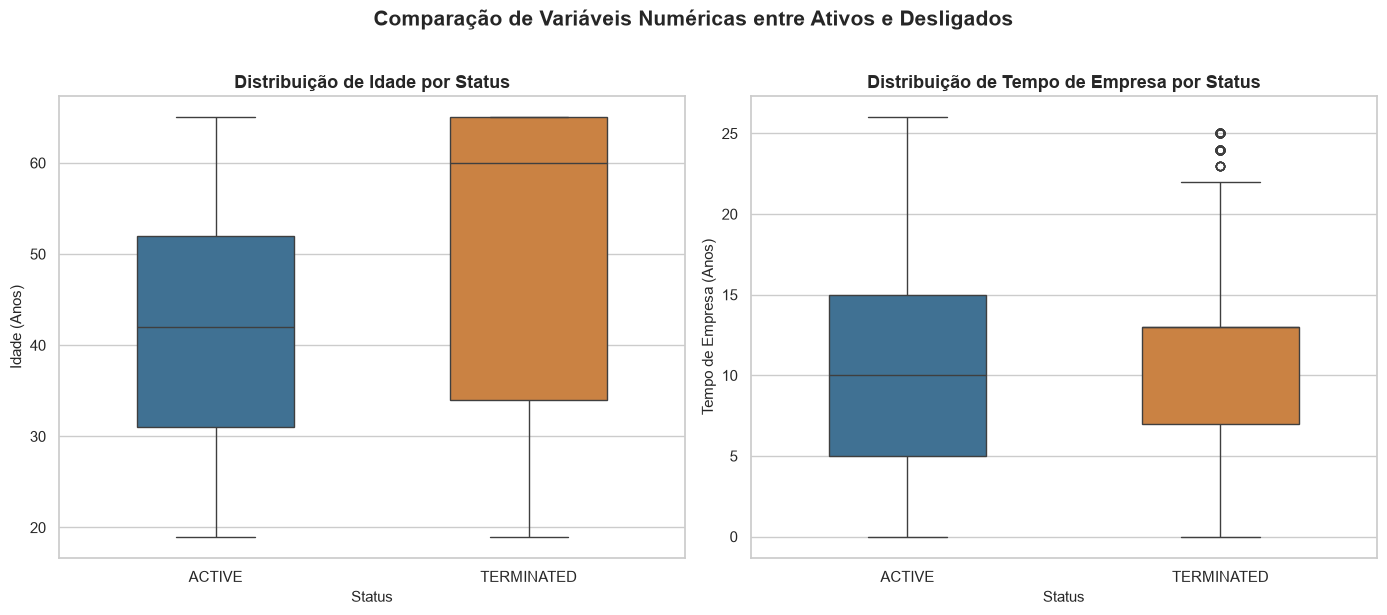

In [7]:
# Boxplots comparativos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot 1: Idade vs Status
sns.boxplot(data=df, x='STATUS', y='age', palette=['#3274a1', '#e1812c'], ax=axes[0], width=0.5)
axes[0].set_title('Distribuição de Idade por Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Status', fontsize=11)
axes[0].set_ylabel('Idade (Anos)', fontsize=11)

# Boxplot 2: Tempo de Empresa vs Status
sns.boxplot(data=df, x='STATUS', y='length_of_service', palette=['#3274a1', '#e1812c'], ax=axes[1], width=0.5)
axes[1].set_title('Distribuição de Tempo de Empresa por Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Status', fontsize=11)
axes[1].set_ylabel('Tempo de Empresa (Anos)', fontsize=11)

plt.suptitle('Comparação de Variáveis Numéricas entre Ativos e Desligados', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

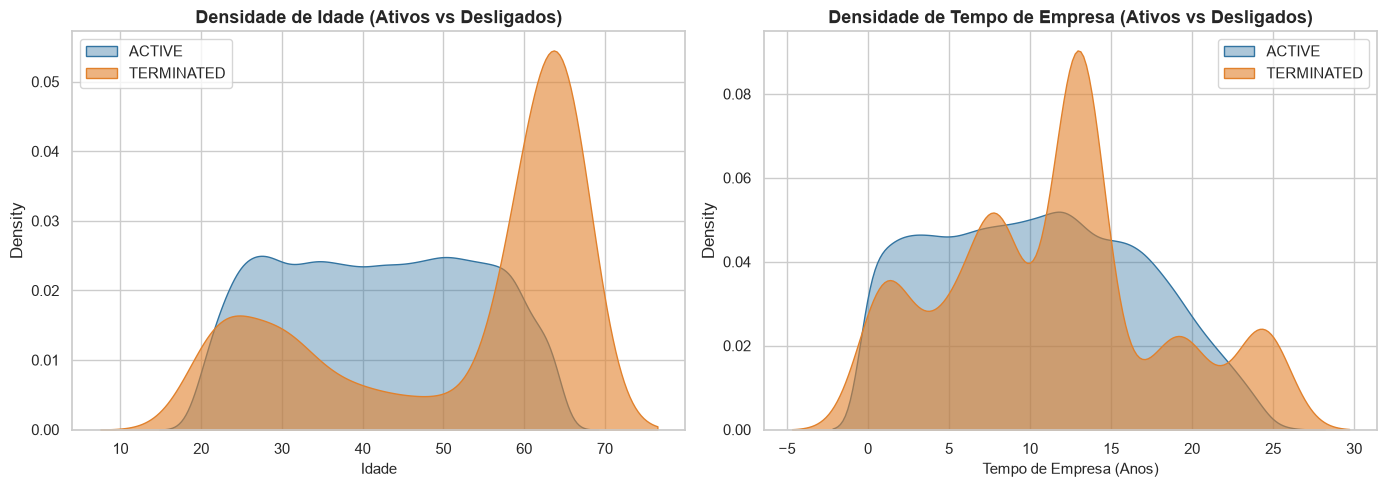

In [8]:
# Gráfico de Densidade (KDE) evidenciando a distribuição bimodal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df[df['STATUS']=='ACTIVE']['age'], label='ACTIVE', fill=True, ax=axes[0], color='#3274a1', alpha=0.4)
sns.kdeplot(data=df[df['STATUS']=='TERMINATED']['age'], label='TERMINATED', fill=True, ax=axes[0], color='#e1812c', alpha=0.6)
axes[0].set_title('Densidade de Idade (Ativos vs Desligados)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Idade', fontsize=11)
axes[0].legend()

sns.kdeplot(data=df[df['STATUS']=='ACTIVE']['length_of_service'], label='ACTIVE', fill=True, ax=axes[1], color='#3274a1', alpha=0.4)
sns.kdeplot(data=df[df['STATUS']=='TERMINATED']['length_of_service'], label='TERMINATED', fill=True, ax=axes[1], color='#e1812c', alpha=0.6)
axes[1].set_title('Densidade de Tempo de Empresa (Ativos vs Desligados)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tempo de Empresa (Anos)', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

#### 📝 Registro da Análise 1:
* **Pergunta**: Colaboradores desligados possuem padrão de idade e tempo de casa diferente dos colaboradores que permanecem ativos?
* **Gráfico**: Boxplots comparativos lado a lado e Gráficos de Densidade (KDE) de `age` e `length_of_service` agrupados por `STATUS`.
* **Observação**: 
  1. A média ($51,46$ anos) e a mediana ($60$ anos) de idade dos desligados são consideravelmente mais altas do que as dos ativos (média de $41,79$ anos e mediana de $42$ anos).
  2. A curva de densidade dos desligados é nitidamente **bimodal**: há um pico expressivo entre $60$ e $65$ anos (aposentadorias) e uma concentração de saídas entre jovens ($20$ a $30$ anos) com pouco tempo de serviço ($0$ a $4$ anos).
* **Hipótese**: O desligamento na organização é composto por dois perfis opostos: a saída natural programada por aposentadoria no topo da carreira (maior volume) e a evasão voluntária de jovens talentos nos primeiros anos de empresa.

---
### 🔬 Análise 2: Categórica × Variável Alvo
#### Impacto da Unidade de Negócio (`BUSINESS_UNIT`) e dos Departamentos no Desligamento

In [9]:
# Tabela cruzada de proporções: Unidade de Negócio vs Status
crosstab_bu = pd.crosstab(df['BUSINESS_UNIT'], df['STATUS'], normalize='index') * 100
print("--- Taxa de Desligamento por Unidade de Negócio (%) ---")
print(crosstab_bu.round(2))

# Detalhamento dos motivos por Unidade de Negócio
print("\n--- Motivos de Desligamento por Unidade de Negócio (Contagem) ---")
print(pd.crosstab(df['BUSINESS_UNIT'], df['termreason_desc']))

--- Taxa de Desligamento por Unidade de Negócio (%) ---
STATUS         ACTIVE  TERMINATED
BUSINESS_UNIT                    
HEADOFFICE      88.21       11.79
STORES          97.11        2.89

--- Motivos de Desligamento por Unidade de Negócio (Contagem) ---
termreason_desc  Layoff  Not Applicable  Resignaton  Retirement
BUSINESS_UNIT                                                  
HEADOFFICE            0             516           1          68
STORES              215           47652         384         817


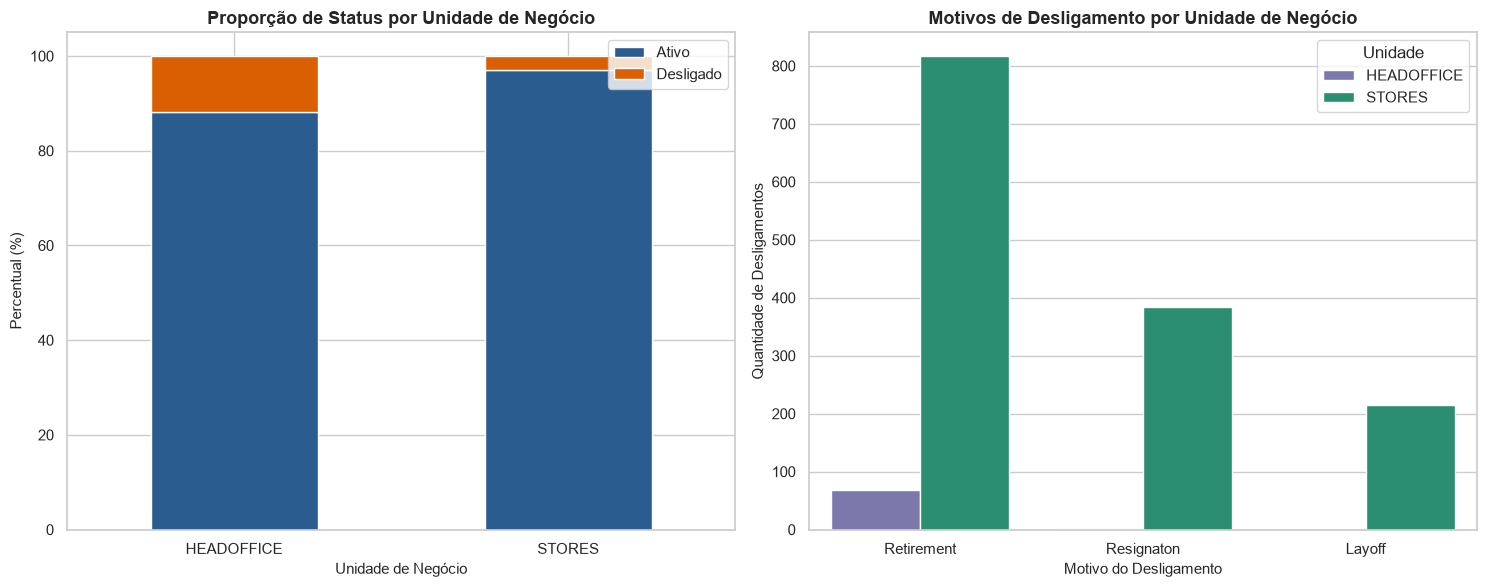

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Proporção de Desligamento por Unidade de Negócio
crosstab_bu.plot(kind='bar', stacked=True, color=['#2b5c8f', '#d95f02'], ax=axes[0])
axes[0].set_title('Proporção de Status por Unidade de Negócio', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Percentual (%)', fontsize=11)
axes[0].set_xlabel('Unidade de Negócio', fontsize=11)
axes[0].legend(['Ativo', 'Desligado'], loc='upper right')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Gráfico 2: Motivos de Desligamento nas Lojas vs Sede
bu_reasons = df[df['STATUS'] == 'TERMINATED']
sns.countplot(data=bu_reasons, x='termreason_desc', hue='BUSINESS_UNIT', palette=['#7570b3', '#1b9e77'], ax=axes[1])
axes[1].set_title('Motivos de Desligamento por Unidade de Negócio', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Motivo do Desligamento', fontsize=11)
axes[1].set_ylabel('Quantidade de Desligamentos', fontsize=11)
axes[1].legend(title='Unidade')

plt.tight_layout()
plt.show()

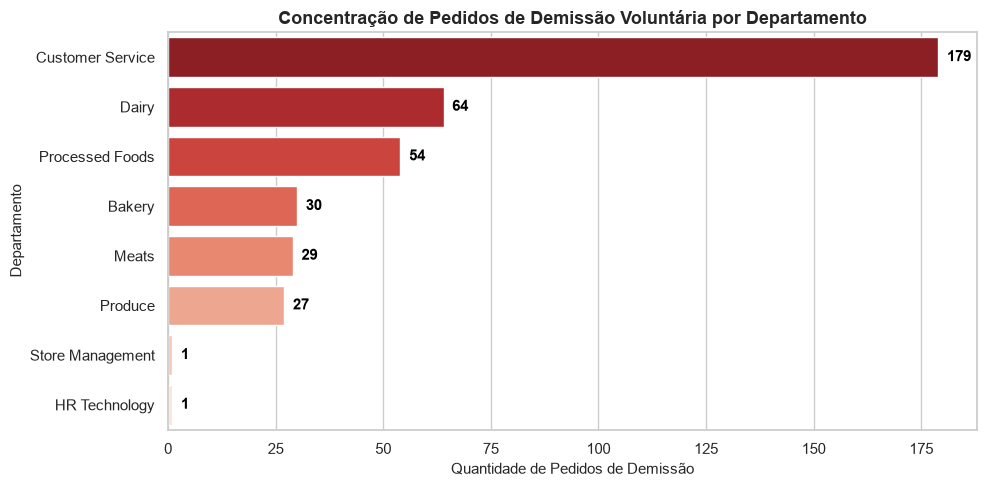

In [11]:
# Top Departamentos com maior volume de pedidos de demissão voluntária (Resignation)
resig_dept = df[df['termreason_desc'] == 'Resignaton']['department_name'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=resig_dept.values, y=resig_dept.index, palette='Reds_r')
plt.title('Concentração de Pedidos de Demissão Voluntária por Departamento', fontsize=13, fontweight='bold')
plt.xlabel('Quantidade de Pedidos de Demissão', fontsize=11)
plt.ylabel('Departamento', fontsize=11)
for i, v in enumerate(resig_dept.values):
    plt.text(v + 2, i, str(v), color='black', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

#### 📝 Registro da Análise 2:
* **Pergunta**: A unidade corporativa (`HEADOFFICE`) e as lojas operacionais (`STORES`) apresentam o mesmo comportamento e motivos de desligamento?
* **Gráfico**: Gráficos de barras empilhadas percentuais (`pd.crosstab`), Countplot de motivos de saída por unidade e gráfico de barras dos departamentos com mais pedidos de demissão.
* **Observação**: 
  1. O `HEADOFFICE` possui uma taxa percentual aparente de desligamento mais alta ($11,79\%$) do que as `STORES` ($2,89\%$). No entanto, no Head Office $98,5\%$ dos desligamentos foram por **Aposentadoria** ($68$ casos) e houve apenas $1$ único pedido de demissão voluntária em 10 anos.
  2. Nas `STORES`, concentram-se $99,7\%$ de todos os pedidos de demissão voluntária ($384$ casos de $385$) e $100\%$ dos desligamentos involuntários/layoffs ($215$ casos).
  3. O setor de Atendimento ao Cliente (`Customer Service`) lidera com folga os pedidos de demissão ($179$ casos, correspondendo a quase metade de todas as demissões voluntárias da empresa).
* **Hipótese**: O escritório central retém talentos até a aposentadoria, enquanto as lojas físicas sofrem com a rotatividade operacional e a sobrecarga típica do atendimento ao cliente no varejo.

---
### 🔬 Análise 3: Numérica × Numérica
#### Relação entre Idade (`age`) e Tempo de Empresa (`length_of_service`) por Motivo de Saída

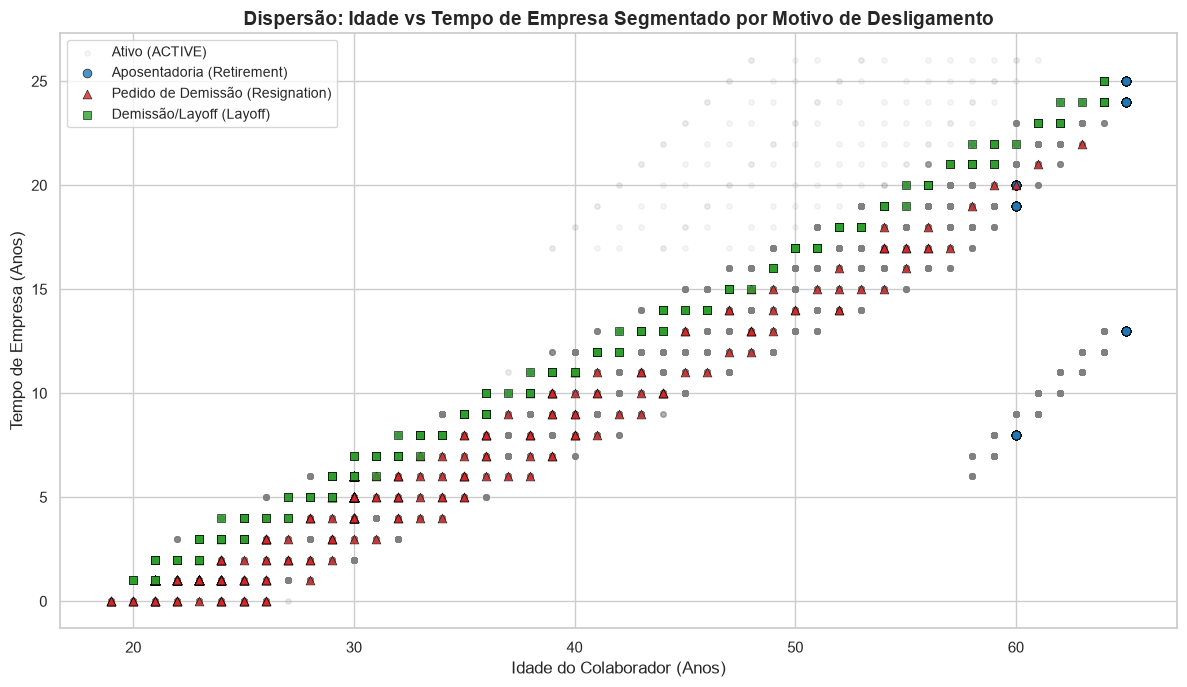

In [12]:
# Scatterplot cruzando Idade vs Tempo de Serviço colorindo pelo Motivo do Desligamento
fig, ax = plt.subplots(figsize=(12, 7))

# Plotando primeiro os ativos como fundo discreto
ax.scatter(df[df['STATUS']=='ACTIVE']['age'], 
           df[df['STATUS']=='ACTIVE']['length_of_service'], 
           alpha=0.08, color='gray', label='Ativo (ACTIVE)', s=15)

# Plotando os desligados com cores vibrantes por motivo
reasons = {'Retirement': ('#1f77b4', 'o', 'Aposentadoria (Retirement)'),
           'Resignaton': ('#d62728', '^', 'Pedido de Demissão (Resignation)'),
           'Layoff': ('#2ca02c', 's', 'Demissão/Layoff (Layoff)')}

for reason, (col, marker, label_text) in reasons.items():
    subset = df[df['termreason_desc'] == reason]
    ax.scatter(subset['age'], subset['length_of_service'], 
               color=col, marker=marker, label=label_text, alpha=0.8, s=40, edgecolors='black', linewidth=0.5)

plt.title('Dispersão: Idade vs Tempo de Empresa Segmentado por Motivo de Desligamento', fontsize=14, fontweight='bold')
plt.xlabel('Idade do Colaborador (Anos)', fontsize=12)
plt.ylabel('Tempo de Empresa (Anos)', fontsize=12)
plt.legend(loc='upper left', frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
# Estatísticas descritivas dos motivos de desligamento
print("--- Média e Desvio Padrão de Idade e Tempo de Serviço por Motivo ---")
print(df[df['STATUS']=='TERMINATED'].groupby('termreason_desc')[['age', 'length_of_service']].agg(['mean', 'std', 'min', 'median', 'max']).round(2))

--- Média e Desvio Padrão de Idade e Tempo de Serviço por Motivo ---
                   age                       length_of_service            \
                  mean    std min median max              mean   std min   
termreason_desc                                                            
Layoff           40.80  13.60  20   39.0  64             11.95  7.29   1   
Resignaton       30.10   9.60  19   29.0  63              4.64  4.70   0   
Retirement       63.34   2.36  60   65.0  65             14.15  5.12   8   

                            
                median max  
termreason_desc             
Layoff            11.0  25  
Resignaton         4.0  22  
Retirement        13.0  25  


#### 📝 Registro da Análise 3:
* **Pergunta**: Como a combinação entre idade e tempo de serviço discrimina os diferentes motivos de saída da organização?
* **Gráfico**: Scatterplot bidimensional (`age` vs `length_of_service`) com marcadores e cores diferenciadas por `termreason_desc`.
* **Observação**: 
  1. O gráfico separa perfeitamente três regiões distintas no espaço de dados:
     * **Pedidos de Demissão (`Resignaton`)**: Concentrados no quadrante inferior esquerdo — jovens de $19$ a $35$ anos (mediana $29$ anos) com pouco tempo de casa ($0$ a $4$ anos).
     * **Aposentadorias (`Retirement`)**: Concentrados estritamente na faixa de $60$ a $65$ anos com tempo de empresa de $8$ a $25$ anos (mediana $13$ anos).
     * **Demissões Involuntárias (`Layoff`)**: Dispersos em uma faixa ampla de idade ($20$ a $60$ anos) e tempo de casa ($0$ a $25$ anos).
* **Hipótese**: A demissão voluntária é um fenômeno concentrado na adaptação inicial de jovens colaboradores, enquanto a aposentadoria é um ciclo previdenciário natural e os layoffs foram ações pontuais da organização.

---
### 🔬 Análise 4: Correlação Multivariada (Heatmap)
#### Matriz de Correlação Linear das Variáveis Numéricas

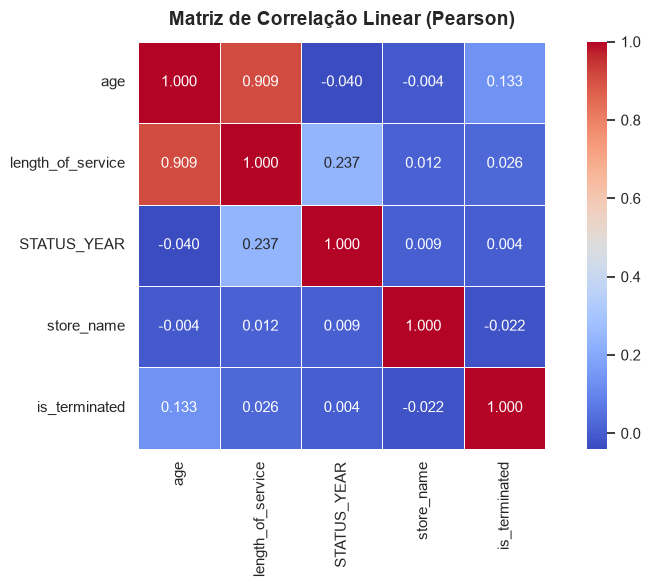

In [14]:
# Criação de variável binária para correlacionar com o target
df_corr = df.copy()
df_corr['is_terminated'] = (df_corr['STATUS'] == 'TERMINATED').astype(int)

# Seleção das colunas numéricas
num_cols = ['age', 'length_of_service', 'STATUS_YEAR', 'store_name', 'is_terminated']
corr_matrix = df_corr[num_cols].corr()

# Heatmap de Correlação
plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', cbar=True, square=True, linewidths=0.5)
plt.title('Matriz de Correlação Linear (Pearson)', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

#### 📝 Registro da Análise 4:
* **Pergunta**: Quais variáveis numéricas apresentam maior correlação linear entre si e com a ocorrência de desligamento?
* **Gráfico**: Heatmap de Correlação Linear de Pearson (`sns.heatmap`) com anotações numéricas.
* **Observação**: 
  1. A correlação entre idade (`age`) e tempo de serviço (`length_of_service`) é quase perfeita e positiva ($r = 0,909$), demonstrando forte estabilidade histórica.
  2. O ano do registro (`STATUS_YEAR`) correlaciona positivamente com o tempo de serviço ($r = 0,237$), refletindo o acompanhamento longitudinal da mesma força de trabalho ao longo de 10 anos.
  3. A correlação linear direta com `is_terminated` é baixa ($r = 0,086$), devido à distribuição bimodal dos desligamentos.
* **Hipótese**: Modelos preditivos baseados em regras e árvores de decisão (Decision Tree, Random Forest, XGBoost) serão mais adequados do que regressões lineares simples.

---
### 🔬 Análise 5: Visualização Interativa com Plotly
#### Exploração Interativa Multidimensional dos Desligamentos

In [15]:
# Amostra para visualização fluida no navegador
sample_df = pd.concat([
    df[df['STATUS'] == 'TERMINATED'],
    df[df['STATUS'] == 'ACTIVE'].sample(n=2000, random_state=42)
])

fig = px.scatter(
    sample_df,
    x='age',
    y='length_of_service',
    color='termreason_desc',
    symbol='BUSINESS_UNIT',
    hover_data=['job_title', 'department_name', 'STATUS_YEAR', 'city_name', 'store_name'],
    title='Exploração Interativa: Idade vs Tempo de Serviço por Motivo e Cargo',
    labels={
        'age': 'Idade (Anos)',
        'length_of_service': 'Tempo de Serviço (Anos)',
        'termreason_desc': 'Motivo do Desligamento',
        'BUSINESS_UNIT': 'Unidade de Negócio'
    },
    color_discrete_map={
        'Not Applicable': '#a6cee3',
        'Retirement': '#1f78b4',
        'Resignaton': '#e31a1c',
        'Layoff': '#33a02c'
    },
    opacity=0.8,
    width=950,
    height=600
)

fig.update_layout(legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))
fig.show()

#### 📝 Registro da Análise 5:
* **Pergunta**: Ao explorar interativamente cargos, lojas e departamentos, quais perfis funcionais concentram os pedidos de demissão?
* **Gráfico**: Scatterplot Interativo com Plotly Express (`px.scatter`), com zoom, filtros de legenda e tooltips informativos.
* **Observação**: Cargos de base operacional em lojas (`Cashier`, `Dairy Person`, `Produce Clerk`) concentram os pontos vermelhos de demissão voluntária (`Resignaton`), enquanto cargos executivos e de liderança (`Director`, `Manager`) aparecem associados aos pontos azuis de aposentadoria aos 65 anos.
* **Hipótese**: O desafio de retenção de talentos da empresa é essencialmente um problema da base operacional de lojas físicas, exigindo políticas de incentivo e planos de progressão voltados a cargos de entrada.

---
### 🔬 Análise 6 (Aprofundamento): Análise Temporal dos Desligamentos (2006 a 2015)
#### Evolução Histórica dos Motivos de Saída ao Longo de 10 Anos

--- Evolução Anual dos Motivos de Desligamento ---
termreason_desc  Layoff  Not Applicable  Resignaton  Retirement
STATUS_YEAR                                                    
2006                  0            4445          12         122
2007                  0            4521          25         137
2008                  0            4603          26         138
2009                  0            4710          18         124
2010                  0            4840          29          94
2011                  0            4972          69          41
2012                  0            5101          76          54
2013                  0            5215          49          56
2014                142            4962          55          56
2015                 73            4799          26          63


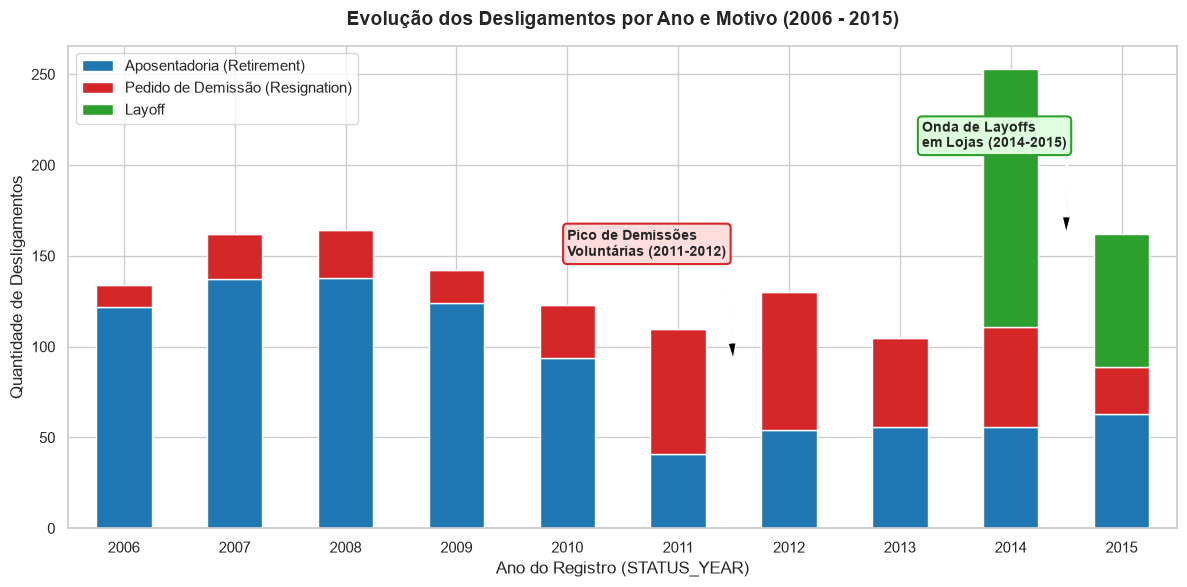

In [16]:
# Tabela de contagem de motivos por ano
temporal_reasons = pd.crosstab(df['STATUS_YEAR'], df['termreason_desc'])
print("--- Evolução Anual dos Motivos de Desligamento ---")
print(temporal_reasons)

# Gráfico de evolução temporal dos motivos de desligamento
fig, ax = plt.subplots(figsize=(12, 6))

temporal_reasons[['Retirement', 'Resignaton', 'Layoff']].plot(
    kind='bar', 
    stacked=True, 
    color=['#1f77b4', '#d62728', '#2ca02c'], 
    ax=ax
)

plt.title('Evolução dos Desligamentos por Ano e Motivo (2006 - 2015)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ano do Registro (STATUS_YEAR)', fontsize=12)
plt.ylabel('Quantidade de Desligamentos', fontsize=12)
plt.legend(['Aposentadoria (Retirement)', 'Pedido de Demissão (Resignation)', 'Layoff'], loc='upper left')
plt.xticks(rotation=0)

# Anotações destacando os marcos temporais
ax.annotate('Pico de Demissões\nVoluntárias (2011-2012)', xy=(5.5, 90), xytext=(4, 150),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
            fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="#ffdddd", ec="#d62728", lw=1.5))

ax.annotate('Onda de Layoffs\nem Lojas (2014-2015)', xy=(8.5, 160), xytext=(7.2, 210),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
            fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="#ddffdd", ec="#2ca02c", lw=1.5))

plt.tight_layout()
plt.show()

In [17]:
# Lojas impactadas pelos Layoffs em 2014 e 2015
layoffs_df = df[df['termreason_desc'] == 'Layoff']
print("--- Lojas mais impactadas por Layoffs (2014 e 2015) ---")
print(layoffs_df['store_name'].value_counts().head(10))

--- Lojas mais impactadas por Layoffs (2014 e 2015) ---
store_name
11    39
20    31
13    30
39    24
14    21
27    17
9     14
37     9
45     6
23     6
Name: count, dtype: int64


#### 📝 Registro da Análise 6:
* **Pergunta**: Como o volume e os motivos de desligamento evoluíram ao longo da década analisada (2006 a 2015)?
* **Gráfico**: Gráfico de barras empilhadas temporal com anotações de eventos históricos.
* **Observação**: 
  1. De $2006$ a $2010$, o padrão foi dominado por cerca de $120$ a $140$ aposentadorias por ano e poucas demissões voluntárias ($12$ a $29$).
  2. Em $2011$ e $2012$, os pedidos de demissão voluntária (`Resignaton`) mais que dobraram, atingindo $69$ e $76$ casos.
  3. Em $2014$ e $2015$, ocorreram demissões em massa inéditas (`Layoff`), com $142$ desligamentos em 2014 e $73$ em 2015, concentrados em lojas físicas específicas (ex: lojas 11, 20, 13 e 39).
* **Hipótese**: Em 2011-2012 houve maior aquecimento de mercado ou pressão operacional no varejo, e em 2014-2015 a empresa executou um plano de reestruturação física com fechamento de filiais menos rentáveis.

---
## 💡 4. Síntese e Descobertas Finais

Ao final desta primeira investigação exploratória (EDA), consolidamos as principais descobertas, hipóteses de negócio e direcionamentos para as próximas etapas:

---
### 🏆 3 Descobertas Encontradas na EDA:

1. **Comportamento Bimodal da Rotatividade**:
   * O desligamento não é homogêneo: divide-se rigidamente entre jovens profissionais ($19$ a $35$ anos) com pouco tempo de casa ($0$ a $4$ anos) pedindo demissão voluntária (`Resignaton`), e profissionais seniores ($60$ a $65$ anos) com longa carreira se aposentando (`Retirement`).
2. **Eventos Críticos e Localizados de Layoff (2014-2015)**:
   * $100\%$ das $215$ demissões involuntárias (`Layoff`) ocorreram nos anos de 2014 e 2015 e afetaram exclusivamente as lojas físicas (`STORES`), com forte concentração em unidades específicas (Lojas 11, 20, 13 e 39).
3. **Abismo Cultural e Estrutural entre Head Office e Stores**:
   * O escritório corporativo (`HEADOFFICE`) registrou apenas $1$ único pedido de demissão voluntária em 10 anos e teve $98,5\%$ de suas saídas motivadas por aposentadoria. Em contrapartida, as lojas físicas concentram $99,7\%$ dos pedidos de demissão da empresa, com liderança absoluta do setor de `Customer Service` ($179$ demissões).

---
### 📈 2 Hipóteses de Negócio:

1. **Hipótese de Fuga de Jovens Talentos no Varejo Operacional**:
   * A ausência de planos de carreira rápidos, baixa atratividade de benefícios de entrada e o alto nível de estresse no atendimento levam colaboradores jovens a utilizarem as lojas apenas como ocupação temporária, deixando a empresa antes de completar 5 anos.
2. **Hipótese de Reestruturação Comercial e Fechamento de Filiais (2014-2015)**:
   * A onda de layoffs em 2014 e 2015 decorreu de decisões estratégicas de encerramento de lojas com baixa rentabilidade ou automação de processos, e não de avaliações individuais de desempenho.

---
### 😲 1 Descoberta Inesperada:

* **Predomínio Absoluto de Aposentadorias e Alta Fidelidade Histórica**:
  * Ao contrário do esperado em bases de turnover (onde normalmente predominam demissões por baixo desempenho ou insatisfação), **$59,6\%$ de todos os desligamentos na empresa foram por Aposentadoria Programada aos 60-65 anos**, revelando que a empresa possui uma força de trabalho com fidelidade e retenção histórica raramente vistas no mercado atual (correlação linear de $0,91$ entre idade e tempo de casa).

---
### ❓ 1 Pergunta que os Dados Ainda Não Permitiram Responder:

* **Qual foi o fator motivador para o salto nos pedidos de demissão voluntária em 2011-2012, e qual era o nível de satisfação salarial e de clima desses colaboradores?**
  * O conjunto de dados não possui variáveis de remuneração (salário, bônus, benefícios), horas extras, notas de avaliação de desempenho ou pesquisa de clima organizacional/entrevista de desligamento. Portanto, não é possível confirmar se as demissões voluntárias decorreram de defasagem salarial, conflitos de liderança ou propostas da concorrência.

---
### 🚀 Próximos Passos Sugeridos para o Squad:
* Criar variáveis derivadas (engenharia de atributos), como faixas etárias, grupos de tempo de casa e flags de risco por departamento/loja.
* Experimentar técnicas de balanceamento de classes (ex.: SMOTE ou pesos balanceados) para os modelos supervisionados.
* Treinar modelos baseados em árvores (Random Forest, LightGBM, XGBoost) capazes de capturar as regras não-lineares de desligamento identificadas nesta EDA.